# 📊 Сравнение алгоритмов поиска пути

В этом ноутбуке проводится экспериментальное сравнение алгоритмов поиска пути на случайно генерируемых гауссовых полях.

## Описание проекта

### 🎯 Цель исследования

Сравнить следующие алгоритмы:

- A*
- Дейкстра
- Жадный (Greedy)

по следующим метрикам:

- время выполнения
- количество посещённых и обработанных узлов
- длина найденного пути (евклидова и пиксельная)
- успешность нахождения пути

### 🧪 Методология

Для каждого запуска:

1. Генерируется поле фиксированного размера (1000x1000) с гаусами с случайными параметрами в заданых диапозонах.
2. Запускаются все алгоритмы на одной и той же карте.
3. Метрики записываются в CSV файл.

#### 📌 Важно

Все алгоритмы сравниваются **на одинаковых входных данных**, что позволяет делать корректные выводы о производительности и качестве решений.

### Задачи исследования

1. Загрузить библиотеки и таблицу
2. Небольшая очистка/подготовка данных
3. Базовая статистика
- Вывод
4. Парное сравнение
- Собрать парные датасеты (A* vs Dijekstra) и  (A* vs Greedy)
- Насколько A* лучше Dijekstra
- Вывод
- Преимущетсва и недостатки Greedy перед A*
- Вывод

## Ход исследования

### 1) Загрузка библиотек и таблицы

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# путь к CSV
path = "../var/metrics/graph.csv"

df = pd.read_csv(path)

df.head()

,environment,algorithm,executionTimeMs,pathNodes,expandedNodes,euclideanLength,pixelLength,pathFound
0,graph,A*,0.374920,65,633,1562.91,1411,1
1,graph,Dijekstra,0.549020,65,1299,1562.91,1411,1
2,graph,Greedy,0.012824,43,43,1464.81,1370,0
3,graph,A*,0.369731,48,584,1550.34,1353,1
4,graph,Dijekstra,0.547710,48,1309,1550.34,1353,1


### 2) Небольшая очистка/подготовка

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   environment      3000 non-null   object 
 1   algorithm        3000 non-null   object 
 2   executionTimeMs  3000 non-null   float64
 3   pathNodes        3000 non-null   int64  
 4   expandedNodes    3000 non-null   int64  
 5   euclideanLength  3000 non-null   float64
 6   pixelLength      3000 non-null   int64  
 7   pathFound        3000 non-null   int64  
dtypes: float64(2), int64(4), object(2)
memory usage: 187.6+ KB


In [3]:
# приводим типы (на всякий случай)
df["executionTimeMs"] = df["executionTimeMs"].astype(float)
df["expandedNodes"] = df["expandedNodes"].astype(int)
df["pathNodes"] = df["pathNodes"].astype(int)
df["pathFound"] = df["pathFound"].astype(int)

df["euclideanLength"] = df["euclideanLength"].astype(float)
df["pixelLength"] = df["pixelLength"].astype(float)

In [4]:
graph = df[df["environment"] == "graph"]

# разделяем по алгоритмам
astar = graph[graph["algorithm"] == "A*"].reset_index(drop=True)
dijkstra = graph[graph["algorithm"] == "Dijekstra"].reset_index(drop=True)
greedy = graph[graph["algorithm"] == "Greedy"].reset_index(drop=True)

# проверяем что строки совпадают по run-логике
n = min(len(astar), len(dijkstra), len(greedy))

astar = astar.iloc[:n]
dijkstra = dijkstra.iloc[:n]
greedy = greedy.iloc[:n]

In [5]:
# оставляем только те запуски, где хотя бы один алгоритм нашел путь
mask = (
    (astar["pathFound"] == 1) |
    (dijkstra["pathFound"] == 1) |
    (greedy["pathFound"] == 1)
)

astar = astar[mask].reset_index(drop=True)
dijkstra = dijkstra[mask].reset_index(drop=True)
greedy = greedy[mask].reset_index(drop=True)

### 3) Базовая статистика


=========== executionTimeMs ===========
            mean  median    std    min    max
algorithm                                    
A*         0.347   0.365  0.085  0.001  0.679
Dijekstra  0.544   0.542  0.041  0.000  0.838
Greedy     0.013   0.013  0.004  0.000  0.058


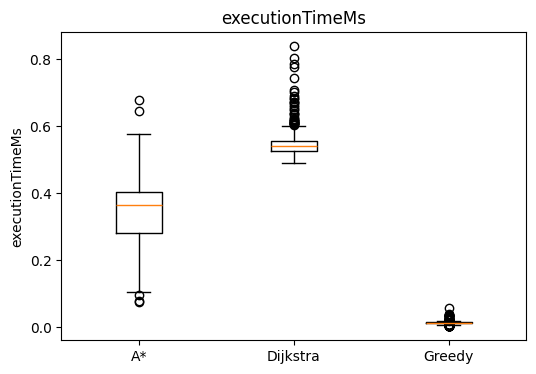


=========== expandedNodes ===========
               mean  median      std  min   max
algorithm                                      
A*          545.279   554.5  136.938    0   929
Dijekstra  1299.922  1302.0   64.059    0  1382
Greedy       43.920    46.0   13.020    0    86


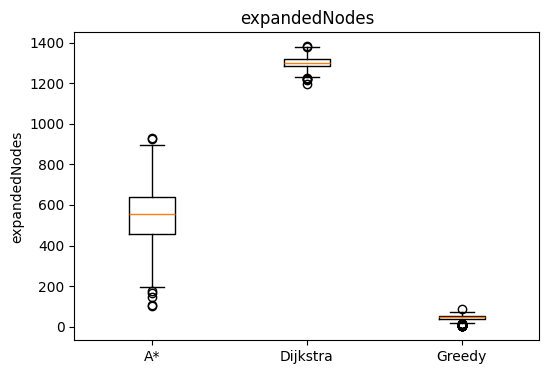


=========== pathNodes ===========
             mean  median     std  min  max
algorithm                                  
A*         49.566    51.0  12.587    0   79
Dijekstra  49.566    51.0  12.587    0   79
Greedy     44.732    47.0  13.148    0   86


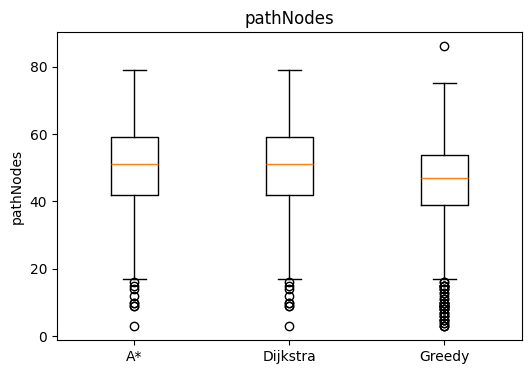


=========== euclideanLength ===========
               mean    median      std  min      max
algorithm                                           
A*         1550.880  1554.855   77.656  0.0  1826.31
Dijekstra  1550.880  1554.855   77.656  0.0  1826.31
Greedy     1763.797  1788.555  309.364  0.0  2338.13


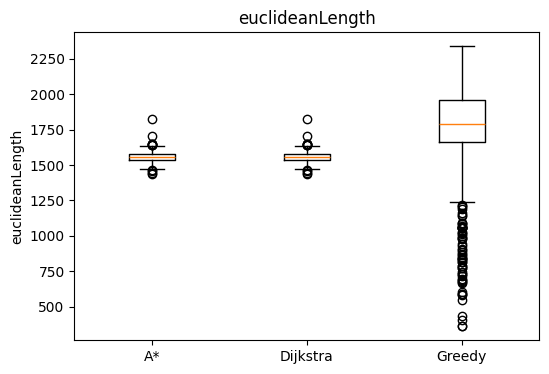


=========== pixelLength ===========
               mean  median      std  min     max
algorithm                                        
A*         1391.975  1400.0   97.590  0.0  1759.0
Dijekstra  1391.975  1400.0   97.590  0.0  1759.0
Greedy     1654.321  1680.0  316.903  0.0  2238.0


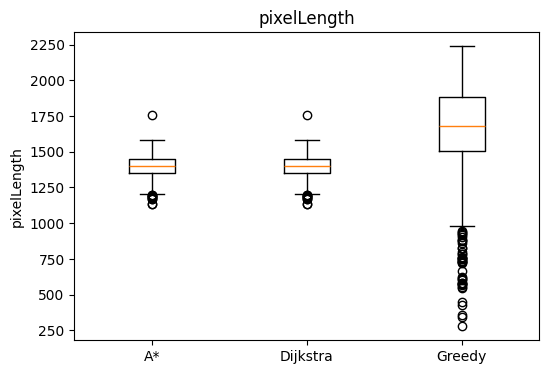


=========== pathFound ===========
            mean  median    std  min  max
algorithm                                
A*         0.998     1.0  0.045    0    1
Dijekstra  0.998     1.0  0.045    0    1
Greedy     0.812     1.0  0.391    0    1


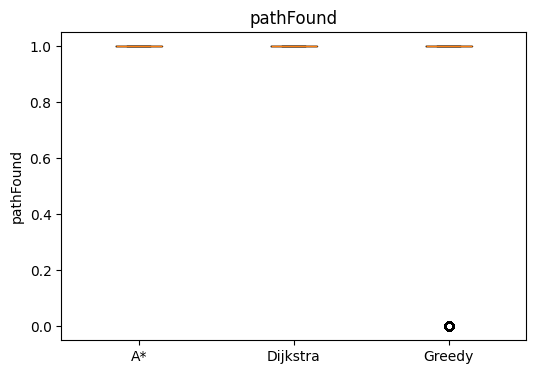

In [6]:
metrics = [
    "executionTimeMs",
    "expandedNodes",
    "pathNodes",
    "euclideanLength",
    "pixelLength",
    "pathFound"
]

for metric in metrics:
    print(f"\n\033[1m=========== {metric} ===========\033[0m")

    summary = (
        graph.groupby("algorithm")[metric]
          .agg(["mean", "median", "std", "min", "max"])
          .round(3)
    )

    print(summary)
    plt.figure(figsize=(6, 4))

    plt.boxplot([
        astar[metric],
        dijkstra[metric],
        greedy[metric]
    ], tick_labels=["A*", "Dijkstra", "Greedy"])

    plt.title(metric)
    plt.ylabel(metric)

    plt.show()

#### Вывод

Базовая статистика подтверждает ожидаемые свойства исследуемых алгоритмов. Алгоритмы A* и Дейкстры демонстрируют одинаковые характеристики построенных маршрутов: число вершин пути, его евклидова и пиксельная длины совпадают во всех проведённых экспериментах, что свидетельствует о построении одинаковых маршрутов. При этом A* достигает этого результата за существенно меньшее время и с меньшим числом расширенных вершин благодаря использованию эвристической функции.

Жадный алгоритм показал наименьшее время работы и минимальное число обработанных вершин, однако это достигается за счёт ухудшения качества решения. В среднем он строит более длинные маршруты и не гарантирует нахождение пути: успешность поиска составила около 80%, тогда как A* и алгоритм Дейкстры успешно находили путь во всех запусках.

Таким образом, уже на этапе базовой статистики наблюдается характерный компромисс между скоростью поиска, качеством найденного маршрута и полнотой поиска. Количественная оценка этих различий будет выполнена в следующем разделе с помощью парного сравнения алгоритмов.

### 4) Парное сравнение

#### A* vs Dijekstra

Смотрим отношения врмени и обработанных вершин (остальные метрики у них совпадают)

In [7]:
time_ratio = (
    dijkstra["executionTimeMs"].to_numpy()
    / astar["executionTimeMs"].to_numpy()
)

expanded_ratio = (
    dijkstra["expandedNodes"].to_numpy()
    / astar["expandedNodes"].to_numpy()
)

comparison = pd.DataFrame({
    "Time ratio": time_ratio,
    "Expanded nodes ratio": expanded_ratio
})

comparison.agg(["mean", "median", "std", "min", "max"]).round(3)

,Time ratio,Expanded nodes ratio
mean,1.700,2.581
median,1.470,2.354
std,0.635,0.916
min,0.848,1.352
max,7.892,12.219


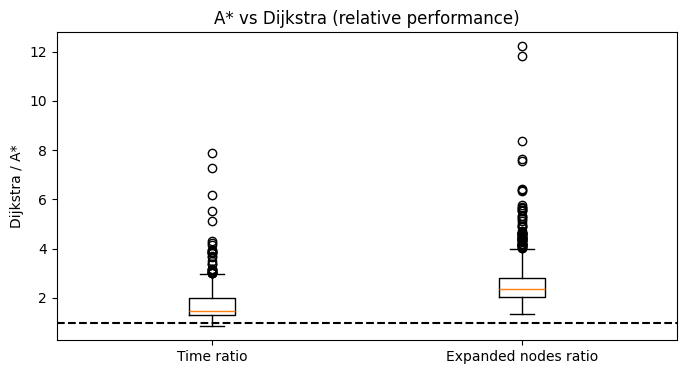

In [8]:
plt.figure(figsize=(8, 4))

plt.boxplot(
    [time_ratio, expanded_ratio],
    tick_labels=["Time ratio", "Expanded nodes ratio"]
)

plt.axhline(1.0, linestyle="--", color="black")

plt.title("A* vs Dijkstra (relative performance)")
plt.ylabel("Dijkstra / A*")

plt.show()

##### Вывод (A* vs Dijkstra)

Парное сравнение алгоритмов показывает устойчивое преимущество A* над алгоритмом Дейкстры по времени выполнения и количеству расширенных вершин при сохранении идентичного качества найденного пути.

По времени работы A* в среднем оказывается быстрее примерно в 1.5 раза, при этом наблюдается умеренный разброс значений, что указывает на зависимость ускорения от структуры конкретного графа.

Более выраженный эффект наблюдается по числу расширенных вершин: A* в среднем исследует в 2 раза меньше узлов, чем алгоритм Дейкстры. Это подтверждает эффективность эвристической компоненты в сокращении пространства поиска.

Таким образом, A* демонстрирует систематическое снижение вычислительных затрат при сохранении оптимальности решения, а выигрыш особенно заметен в метрике числа расширенных состояний, что согласуется с теоретическими свойствами алгоритма.

#### A* vs Greedy

Подготовка метрик


=== time_ratio ===
mean      0.040
median    0.038
std       0.017
min       0.007
max       0.192
Name: time_ratio, dtype: float64


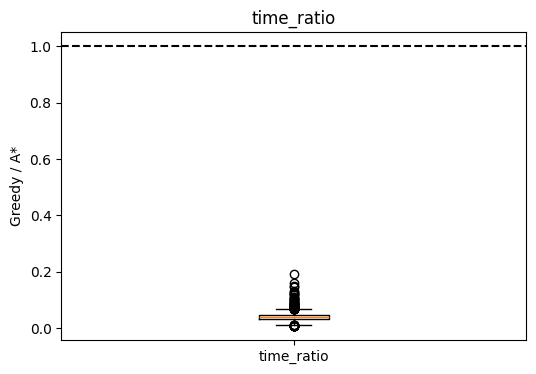


=== nodes_ratio ===
mean      0.085
median    0.083
std       0.035
min       0.004
max       0.453
Name: nodes_ratio, dtype: float64


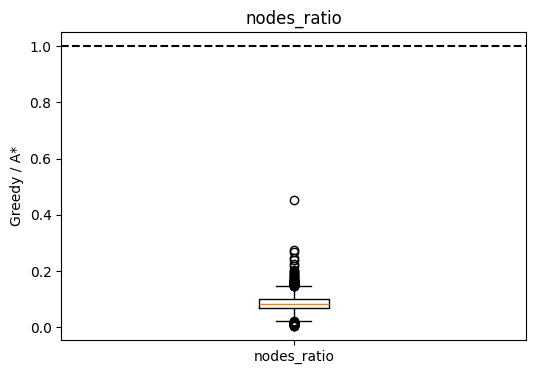


=== path_nodes_ratio ===
mean      0.952
median    0.943
std       0.359
min       0.058
max       5.000
Name: path_nodes_ratio, dtype: float64


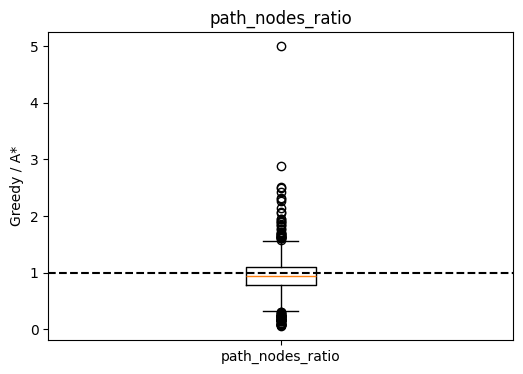


=== euclid_ratio ===
mean      1.137
median    1.146
std       0.189
min       0.227
max       1.475
Name: euclid_ratio, dtype: float64


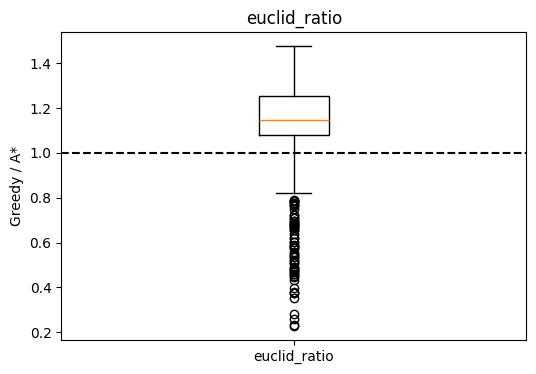


=== pixel_ratio ===
mean      1.188
median    1.194
std       0.211
min       0.205
max       1.641
Name: pixel_ratio, dtype: float64


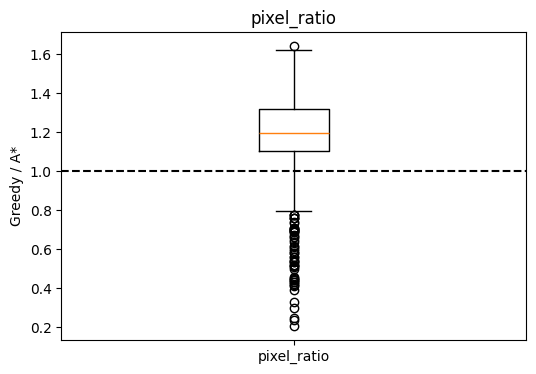

In [9]:
ratios = {
    "time_ratio": greedy["executionTimeMs"].to_numpy() / astar["executionTimeMs"].to_numpy(),
    "nodes_ratio": greedy["expandedNodes"].to_numpy() / astar["expandedNodes"].to_numpy(),
    "path_nodes_ratio": greedy["pathNodes"].to_numpy() / astar["pathNodes"].to_numpy(),
    "euclid_ratio": greedy["euclideanLength"].to_numpy() / astar["euclideanLength"].to_numpy(),
    "pixel_ratio": greedy["pixelLength"].to_numpy() / astar["pixelLength"].to_numpy(),
}

ratio_df = pd.DataFrame(ratios)

for name in ratio_df.columns:
    print(f"\n\033[1m=== {name} ===\033[0m")

    summary = ratio_df[name].agg(["mean", "median", "std", "min", "max"]).round(3)
    print(summary)

    plt.figure(figsize=(6, 4))

    plt.boxplot([ratio_df[name]], tick_labels=[name])
    plt.axhline(1.0, linestyle="--", color="black")

    plt.title(name)
    plt.ylabel("Greedy / A*")

    plt.show()

##### Вывод (Greedy vs A*)

Парное сравнение алгоритмов Greedy и A* демонстрирует выраженный компромисс между вычислительной эффективностью и качеством решения.

По времени выполнения Greedy значительно превосходит A*, обеспечивая ускорение в среднем примерно в 25 раз. Аналогичная тенденция наблюдается и по числу обработанных вершин: Greedy рассматривает в среднем в 12 раз меньше узлов от количества, обрабатываемого A*, что подтверждает его значительно меньшую вычислительную сложность.

Однако это ускорение достигается ценой ухудшения качества решения. Длина найденного пути у Greedy в среднем увеличивается. При этом наблюдается существенная вариативность результатов, что указывает на зависимость качества пути от структуры конкретной карты.

Отдельно следует отметить, что Greedy не гарантирует полноту поиска: в части экспериментов алгоритм не смог найти путь, тогда как A* всегда находил корректное решение. Это подчёркивает фундаментальное отличие эвристического жадного поиска от алгоритма, сохраняющего оптимальность и полноту.

Таким образом, Greedy демонстрирует максимальную скорость работы и минимальные вычислительные затраты, но проигрывает по надёжности и качеству маршрута. В отличие от него, A* обеспечивает устойчиво оптимальные пути ценой увеличенных вычислений.